### This is the overall diagram for understanding RAG



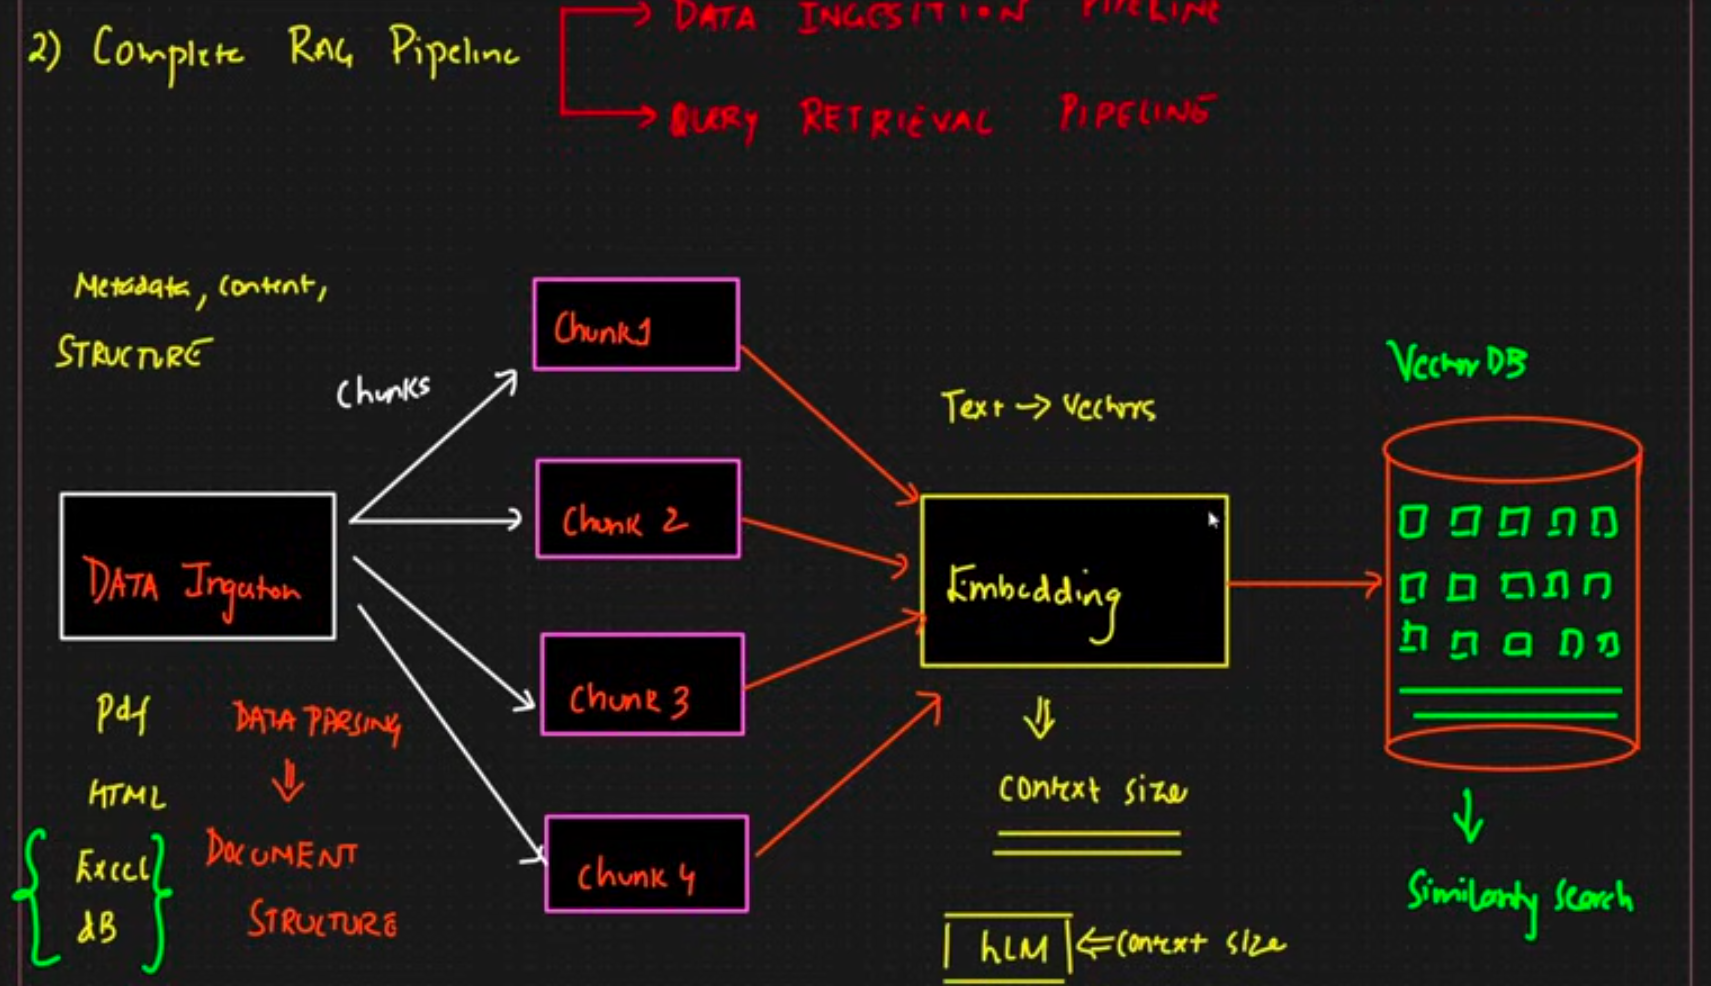

In [1]:
from IPython.display import Image
Image("image1.png")

Data Injestion

In [2]:
## Document structure

from langchain_core.documents import Document

In [3]:
doc =  Document(
    page_content = "this is the main content i using to create a RAG",
    metadata = {
        "source":"example.txt",
        "pages":1,
        "author":"Aditya Asutosh Mishra",
        "data_created":"2026-05-18"
    }
)

## meta data: it means the details of the given file like author name, date created, source, pages


In [4]:
doc

Document(metadata={'source': 'example.txt', 'pages': 1, 'author': 'Aditya Asutosh Mishra', 'data_created': '2026-05-18'}, page_content='this is the main content i using to create a RAG')

In [5]:
## create a simple txt file

import os
os.makedirs("../data/text_files",exist_ok=True)

In [6]:
sample_texts = {
    "../data/text_files/rag_intro.txt":"""Retrieval-Augmented Generation (RAG) enhances large language models by integrating external, up-to-date data into the response generation process.  This approach reduces hallucinations and improves the accuracy and relevance of AI outputs by grounding them in verified sources. 

→ Ingestion: External data (PDFs, databases, web pages) is loaded and standardized for processing.
→ Chunking & Embedding: Documents are split into manageable segments and converted into semantic vectors using embedding models like BioBERT or FinBERT.
→ Vector Storage: Embedded chunks are stored in a vector database such as Pinecone or Weaviate for fast similarity search.
→ Retrieval: On a user query, the system retrieves the most relevant document chunks using semantic search, often enhanced with hybrid methods (e.g., BM25 + vectors).
→ Re-ranking: Retrieved results are refined using a cross-encoder model to improve precision.
→ Generation: The final response is generated by combining the top-ranked context with the query in a prompt fed to the LLM.
→ Evaluation: Performance is monitored using metrics like Recall@k, Faithfulness, and RAGAs to ensure quality and enable continuous improvement.
"""
}

for filepath,content in sample_texts.items():
    with open(filepath,'w',encoding="utf-8") as f:
        f.write(content)
    

print("🟢Sample text files created!")

### to enter the content in the given text file


🟢Sample text files created!


In [7]:
### Text loader

from langchain_community.document_loaders import TextLoader
loader = TextLoader("../data/text_files/rag_intro.txt",encoding="utf-8")
document = loader.load()
print(document)




/home/aditya/RAG/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Document(metadata={'source': '../data/text_files/rag_intro.txt'}, page_content='Retrieval-Augmented Generation (RAG) enhances large language models by integrating external, up-to-date data into the response generation process.  This approach reduces hallucinations and improves the accuracy and relevance of AI outputs by grounding them in verified sources. \n\n→ Ingestion: External data (PDFs, databases, web pages) is loaded and standardized for processing.\n→ Chunking & Embedding: Documents are split into manageable segments and converted into semantic vectors using embedding models like BioBERT or FinBERT.\n→ Vector Storage: Embedded chunks are stored in a vector database such as Pinecone or Weaviate for fast similarity search.\n→ Retrieval: On a user query, the system retrieves the most relevant document chunks using semantic search, often enhanced with hybrid methods (e.g., BM25 + vectors).\n→ Re-ranking: Retrieved results are refined using a cross-encoder model to improve precisio

In [8]:
### Directory Loader
from langchain_community.document_loaders import DirectoryLoader

## load all the text files from the directory

dir_loader = DirectoryLoader(
    "../data/text_files",
    glob = "**/*.txt", ## Pattern to match files
    loader_cls = TextLoader, #3 loader class to use
    loader_kwargs = {'encoding':'utf-8'},
    show_progress=False
)

documents = dir_loader.load()


In [9]:
documents

[Document(metadata={'source': '../data/text_files/rag_intro.txt'}, page_content='Retrieval-Augmented Generation (RAG) enhances large language models by integrating external, up-to-date data into the response generation process.  This approach reduces hallucinations and improves the accuracy and relevance of AI outputs by grounding them in verified sources. \n\n→ Ingestion: External data (PDFs, databases, web pages) is loaded and standardized for processing.\n→ Chunking & Embedding: Documents are split into manageable segments and converted into semantic vectors using embedding models like BioBERT or FinBERT.\n→ Vector Storage: Embedded chunks are stored in a vector database such as Pinecone or Weaviate for fast similarity search.\n→ Retrieval: On a user query, the system retrieves the most relevant document chunks using semantic search, often enhanced with hybrid methods (e.g., BM25 + vectors).\n→ Re-ranking: Retrieved results are refined using a cross-encoder model to improve precisio

In [10]:
from langchain_community.document_loaders import PyPDFLoader,PyMuPDFLoader

### Directory Loader
from langchain_community.document_loaders import DirectoryLoader

## load all the text files from the directory

dir_loader = DirectoryLoader(
    "../data/pdf",
    glob = "**/*.pdf", ## Pattern to match files
    loader_cls = PyMuPDFLoader, #3 loader class to use
    show_progress=False
)

pdf_documents = dir_loader.load()


In [11]:
pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-28T16:37:18+00:00', 'source': '../data/pdf/Aditya_Asutosh_Mishra_Resume.pdf', 'file_path': '../data/pdf/Aditya_Asutosh_Mishra_Resume.pdf', 'total_pages': 1, 'format': 'PDF 1.5', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2026-03-28T16:37:18+00:00', 'trapped': '', 'modDate': 'D:20260328163718Z', 'creationDate': 'D:20260328163718Z', 'page': 0}, page_content='Aditya Asutosh Mishra\nBhubaneswar, OD 751002\n\x83 +91 9040029407\n# adityaasutoshmishra2005@gmail.com\nï linkedin.com/in/aditya-asutosh-mishra\n§\ngithub.com/adityaDev-2005\nSummary\nAspiring Machine Learning Engineer and Full-Stack Developer with hands-on experience in designing and evaluating machine\nlearning models across computer vision, natural language processing, and deep learning domains. Proficient in building\nconvolutional neural networks (CNNs) for image classification tasks including 

In [12]:
type(pdf_documents[0])

langchain_core.documents.base.Document

Stoped at 52:05

### Flow of the RAG pipeline

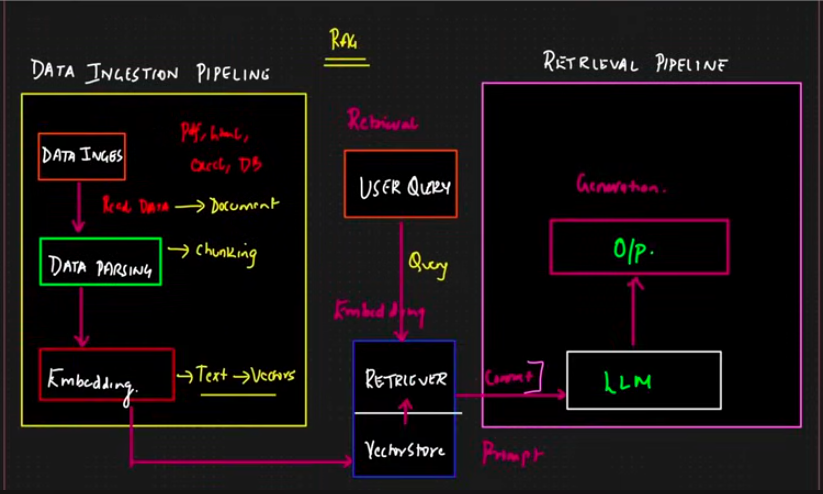

In [13]:
from IPython.display import Image
Image("image2.png")

RAG Pipelines- Data Ingestion to Vector DB Pipeline


In [14]:
import os
from langchain_community.document_loaders import PyPDFLoader, PyMuPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path

In [15]:
### Read all the pdf's inside the directory

def process_all_pdfs(pdf_directory):
    """Process all PDF files in a directory"""

    all_documents = []
    pdf_dir = Path(pdf_directory) 

    # Find all PDF files recursively
    pdf_files = list(pdf_dir.glob("**/*.pdf"))

    print(f"Found {len(pdf_files)} PDF files to process")

    for pdf_file in pdf_files:
        print(f"\nProcessig: {pdf_file.name}")
        try:
            loader = PyPDFLoader(str(pdf_file))
            documents = loader.load()

            # Add source information to metadata
            for doc in documents:
                doc.metadata['source_file'] = pdf_file.name
                doc.metadata['file_type'] = 'pdf'

            all_documents.extend(documents)
            print(f"Loaded {len(documents)} pages")

        except Exception as e:
            print(f"Error:{e}")
    
    print(f"\nTotal documents loaded:{len(all_documents)}")
    return all_documents


# Process all the PDFs in the data directory

all_pdf_documents = process_all_pdfs("../data")
    

Found 2 PDF files to process

Processig: Aditya_Asutosh_Mishra_Resume.pdf
Loaded 1 pages

Processig: attention is all you need.pdf
Loaded 11 pages

Total documents loaded:12


In [16]:
all_pdf_documents

[Document(metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-28T16:37:18+00:00', 'author': '', 'keywords': '', 'moddate': '2026-03-28T16:37:18+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/pdf/Aditya_Asutosh_Mishra_Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'source_file': 'Aditya_Asutosh_Mishra_Resume.pdf', 'file_type': 'pdf'}, page_content='Aditya Asutosh Mishra\nBhubaneswar, OD 751002\n♂phone+91 9040029407 /envel⌢peadityaasutoshmishra2005@gmail.com /linkedinlinkedin.com/in/aditya-asutosh-mishra /github\ngithub.com/adityaDev-2005\nSummary\nAspiring Machine Learning Engineer and Full-Stack Developer with hands-on experience in designing and evaluating machine\nlearning models across computer vision, natural language processing, and deep learning domains. Proficient in building\nconvol

In [17]:
### Text splitting get into chunks

def split_documents(documents,chunk_size=1000,chunk_overlap=200):
    """Split documents into smaller chunks for better RAG performance"""

    text_splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        length_function=len,
        separators=["\n\n","\n"," ", ""]
    )

    split_docs = text_splitter.split_documents(documents)
    print(f"Split {len(documents)} documents into {len(split_docs)} chunks")

    # Show example of a chunk
    if split_docs:
        print(f"\nExample chunk:")
        print(f"Content: {split_docs[0].page_content[:200]}...")
        print(f"Metadata: {split_docs[0].metadata}")

    return split_docs

In [18]:
chunks = split_documents(all_pdf_documents)

Split 12 documents into 48 chunks

Example chunk:
Content: Aditya Asutosh Mishra
Bhubaneswar, OD 751002
♂phone+91 9040029407 /envel⌢peadityaasutoshmishra2005@gmail.com /linkedinlinkedin.com/in/aditya-asutosh-mishra /github
github.com/adityaDev-2005
Summary
As...
Metadata: {'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-28T16:37:18+00:00', 'author': '', 'keywords': '', 'moddate': '2026-03-28T16:37:18+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/pdf/Aditya_Asutosh_Mishra_Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'source_file': 'Aditya_Asutosh_Mishra_Resume.pdf', 'file_type': 'pdf'}


In [19]:
chunks

[Document(metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-28T16:37:18+00:00', 'author': '', 'keywords': '', 'moddate': '2026-03-28T16:37:18+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/pdf/Aditya_Asutosh_Mishra_Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'source_file': 'Aditya_Asutosh_Mishra_Resume.pdf', 'file_type': 'pdf'}, page_content='Aditya Asutosh Mishra\nBhubaneswar, OD 751002\n♂phone+91 9040029407 /envel⌢peadityaasutoshmishra2005@gmail.com /linkedinlinkedin.com/in/aditya-asutosh-mishra /github\ngithub.com/adityaDev-2005\nSummary\nAspiring Machine Learning Engineer and Full-Stack Developer with hands-on experience in designing and evaluating machine\nlearning models across computer vision, natural language processing, and deep learning domains. Proficient in building\nconvol

Embedding and vectorStoreDB

In [20]:
import numpy as np
from sentence_transformers import SentenceTransformer
import chromadb  ## a vector database storage for vector embeddings
from chromadb.config import Settings
import uuid
from typing import List, Dict, Any, Tuple
from sklearn.metrics.pairwise import cosine_similarity

In [21]:
class EmbeddingManager:
    """Handles document embedding generation using SentenceTransformer"""

    def __init__(self, model_name:str="all-miniLM-L6-v2"):
        ### all-miniLM-L6-v2 : a lightweight efficient sentence transformer model by Microsoft that maps sentences and short paragraphs into a 384-dimensional dense vector space

        """
        Initialize the embedding manager

        Args:
            model name: HuggingFace model name for sentence embeddings
        """

        self.model_name = model_name
        self.model = None
        self._load_model()


    def _load_model(self):
        """Load the Sentence Transformer model"""
        try:
            print(f"Loading embedding model:{self.model_name}")
            self.model = SentenceTransformer(self.model_name)
            print(f"Model loaded successfully. Embedding dimension:{self.model.get_sentence_embedding_dimension()}")
        except Exception as e:
            print(f"Error loading model {self.model_name}: {e}")
            raise ## raise or manually trigger an exception when a specific condition arises
    

    def generate_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Generate embeddings for a list of texts

        Args:
            texts: List of text strings to embed
        Returns:
            numpy array of embedddings with shape (len(texts), embedding_dim)
        """

        if not self.model:
            raise ValueError("Model not loaded")
        

        print(f"Generateing embeddings for {len(texts)} texts...")
        embeddings = self.model.encode(texts, show_progress_bar=True)
        print(f"Generated embeddings with shape: {embeddings.shape}")
        return embeddings
    
    # def get_embedding_dimensions(self) -> int:
    #     """Get the embedding  dimension of the model"""

    #     if not self.model:
    #         raise ValueError("Model not loaded")
    #     return self.model.get_sentence_embedding_dimension()


    ### initialize the embedding manager

embedding_manager = EmbeddingManager()
embedding_manager


Loading embedding model:all-miniLM-L6-v2


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2508.37it/s]


Model loaded successfully. Embedding dimension:384


/tmp/ipykernel_5809/2288609017.py:24: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print(f"Model loaded successfully. Embedding dimension:{self.model.get_sentence_embedding_dimension()}")


### VectorStore

In [22]:
class VectorStore:
    """Manages document embeddings in a ChromaDB vector store"""

    def __init__(self, collection_name:str="pdf_documents", persist_directory:str ="../data/vector_store"):
        """
        Initialize the vector store

        Args:
            collection_name: Name of the ChromaDB collection
            persist_directory: Directory to persist the vector store
        """

        self.collection_name = collection_name
        self.persist_directory = persist_directory
        self.client = None
        self.collection = None
        self._initialize_store()

    def _initialize_store(self):
        """Initialize ChromaDB client and collection"""
        try:

            # Create persistant ChromaDB client
            os.makedirs(self.persist_directory, exist_ok=True)
            self.client = chromadb.PersistentClient(path=self.persist_directory)

            # Get or create collection
            self.collection = self.client.get_or_create_collection(
                name=self.collection_name,
                metadata={"description":"PDF document embeddings for RAG"}
            )
            print(f"Vector store initialized. Collection: {self.collection_name}")
            print(f"Existing documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error initializing vector store: {e}")
            raise

    def add_documents(self, documents: List[Any], embeddings: np.ndarray):
        """
        Add documents and their embeddings to the vector store

        Args:
            documents: List of Langchain documents
            embeddings: Corresponding embeddings for the documents
        """

        if len(documents) != len(embeddings):
            raise ValueError("Number of documents must match number of embeddings")
        
        print(f"Adding {len(documents)} documents to vector store...")

        # Prepare data for ChromaDB

        ids = []
        metadatas = []
        documents_text = []
        embeddings_list = []

        for i, (doc, embedding) in enumerate(zip(documents, embeddings)):
            # Generate unique ID
            doc_id = f"doc_{uuid.uuid4().hex[:8]}_{i}"
            ids.append(doc_id)

            # Prepare metadata
            metadata = dict(doc.metadata)
            metadata['doc_index'] = i
            metadata['content_length'] = len(doc.page_content)
            metadatas.append(metadata)

            # Document content
            documents_text.append(doc.page_content)

            # Embedding
            embeddings_list.append(embedding.tolist())

        # Add to the collection
        try:
            self.collection.add(
                ids=ids,
                embeddings=embeddings_list,
                metadatas=metadatas,
                documents=documents_text
            )
            print(f"Successfully added {len(documents)} documents to vector store")
            print(f"Total documents in collection: {self.collection.count()}")

        except Exception as e:
            print(f"Error adding elements to vector store: {e}")
            raise

vectorstore = VectorStore()
vectorstore



Vector store initialized. Collection: pdf_documents
Existing documents in collection: 48


In [23]:
chunks

[Document(metadata={'producer': 'pdfTeX-1.40.27', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-03-28T16:37:18+00:00', 'author': '', 'keywords': '', 'moddate': '2026-03-28T16:37:18+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live 2025) kpathsea version 6.4.1', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/pdf/Aditya_Asutosh_Mishra_Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'source_file': 'Aditya_Asutosh_Mishra_Resume.pdf', 'file_type': 'pdf'}, page_content='Aditya Asutosh Mishra\nBhubaneswar, OD 751002\n♂phone+91 9040029407 /envel⌢peadityaasutoshmishra2005@gmail.com /linkedinlinkedin.com/in/aditya-asutosh-mishra /github\ngithub.com/adityaDev-2005\nSummary\nAspiring Machine Learning Engineer and Full-Stack Developer with hands-on experience in designing and evaluating machine\nlearning models across computer vision, natural language processing, and deep learning domains. Proficient in building\nconvol

In [24]:
# Delete all documents in current collection
all_docs = vectorstore.collection.get()

vectorstore.collection.delete(
    ids=all_docs['ids']
)

print(vectorstore.collection.count())

"""
so earlier i ran the given below code multiple times so it produced copies of the given document
so this code deleted the exisiting docs and then again i ran the code and now it added freshly.
"""

0


'\nso earlier i ran the given below code multiple times so it produced copies of the given document\nso this code deleted the exisiting docs and then again i ran the code and now it added freshly.\n'

In [25]:
### Convert the text to embeddings
## stopped at 1:15:29

texts = [doc.page_content for doc in chunks]
## texts

## Generate the embeddings
embeddings = embedding_manager.generate_embeddings(texts)

## Store in the vectore database
vectorstore.add_documents(chunks,embeddings)

Generateing embeddings for 48 texts...


Batches: 100%|██████████| 2/2 [00:00<00:00,  3.92it/s]

Generated embeddings with shape: (48, 384)
Adding 48 documents to vector store...
Successfully added 48 documents to vector store
Total documents in collection: 48


### Retrieval Pipeline from VectorStore(IMPORTANT🎯)

In [26]:
from typing import List, Dict, Any
from pprint import pprint

class RAGRetriever:
    """Handles query-based retrieval from the vector store"""

    def __init__(self, vector_store: VectorStore, embedding_manager: EmbeddingManager):
        """
        Initialize the retriever

        Args:
            vector_store: Vector store containing document embeddings
            embedding_manager: Manager for generating query embeddings
        """
        self.vector_store = vector_store
        self.embedding_manager = embedding_manager


    def retrieve(self, query: str, top_k: int = 5) -> List[Dict[str, Any]]:
        """
        Retrieve relevant documents for a query

        Args:
            query: Search query
            top_k: Number of results

        Returns:
            List of retrieved documents
        """

        print(f"\nRetrieving documents for query: '{query}'")
        print(f"Top K: {top_k}")

        # Generate query embedding
        query_embedding = self.embedding_manager.generate_embeddings([query])[0]

        try:
            results = self.vector_store.collection.query(
                query_embeddings=[query_embedding.tolist()],
                n_results=top_k,
                include=["documents", "metadatas", "distances"]
            )

            retrieved_docs = []

            if results["documents"] and len(results["documents"][0]) > 0:

                documents = results["documents"][0]
                metadatas = results["metadatas"][0]
                distances = results["distances"][0]
                ids = results["ids"][0]

                for i, (doc_id, document, metadata, distance) in enumerate(
                    zip(ids, documents, metadatas, distances)
                ):

                    retrieved_docs.append({
                        "id": doc_id,
                        "content": document,
                        "metadata": metadata,
                        "distance": round(distance, 4),
                        "rank": i + 1
                    })

                print(f"\nRetrieved {len(retrieved_docs)} documents\n")

                # Vertical display
                for doc in retrieved_docs:
                    print("=" * 80)
                    print(f"Rank: {doc['rank']}")
                    print(f"ID: {doc['id']}")
                    print(f"Distance: {doc['distance']}")

                    print("\nContent:")
                    print(doc["content"][:500])

                    print("\nMetadata:")
                    pprint(doc["metadata"])

                    print("=" * 80)

            else:
                print("No documents found")

            return retrieved_docs

        except Exception as e:
            print(f"Error during retrieval: {e}")
            return []

In [27]:
rag_retriever = RAGRetriever(vectorstore, embedding_manager)

results = rag_retriever.retrieve(
    "what is attention is all you need"
)


Retrieving documents for query: 'what is attention is all you need'
Top K: 5
Generateing embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 11.73it/s]

Generated embeddings with shape: (1, 384)

Retrieved 5 documents

Rank: 1
ID: doc_607776fb_30
Distance: 1.1447

Content:
convolution is equal to the combination of a self-attention layer and a point-wise feed-forward layer,
the approach we take in our model.
As side beneﬁt, self-attention could yield more interpretable models. We inspect attention distributions
from our models and present and discuss examples in the appendix. Not only do individual attention
heads clearly learn to perform different tasks, many appear to exhibit behavior related to the syntactic
and semantic structure of the sentences.
5 Training
T

Metadata:
{'author': 'Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion '
           'Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin',
 'book': 'Advances in Neural Information Processing Systems 30',
 'content_length': 970,
 'created': '2017',
 'creationdate': '',
 'creator': 'PyPDF',
 'date': '2017',
 'description': 'Paper accepted and presented at t

In [28]:
results = rag_retriever.retrieve(
    "Education"
)

## here i gave the query education and which is in the reume pdf which i added so it retrieved the information


Retrieving documents for query: 'Education'
Top K: 5
Generateing embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 216.75it/s]

Generated embeddings with shape: (1, 384)

Retrieved 5 documents

Rank: 1
ID: doc_bb26270b_0
Distance: 1.3615

Content:
Aditya Asutosh Mishra
Bhubaneswar, OD 751002
♂phone+91 9040029407 /envel⌢peadityaasutoshmishra2005@gmail.com /linkedinlinkedin.com/in/aditya-asutosh-mishra /github
github.com/adityaDev-2005
Summary
Aspiring Machine Learning Engineer and Full-Stack Developer with hands-on experience in designing and evaluating machine
learning models across computer vision, natural language processing, and deep learning domains. Proficient in building
convolutional neural networks (CNNs) for image classification 

Metadata:
{'author': '',
 'content_length': 970,
 'creationdate': '2026-03-28T16:37:18+00:00',
 'creator': 'LaTeX with hyperref',
 'doc_index': 0,
 'file_type': 'pdf',
 'keywords': '',
 'moddate': '2026-03-28T16:37:18+00:00',
 'page': 0,
 'page_label': '1',
 'producer': 'pdfTeX-1.40.27',
 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.27 (TeX Live '
        

stopped at 1:30:32

### Now that we can see retrieval is working so we need the last part which is to give it to the LLM and then get the output

### Integration Vectordb Context pipeline With LLM output

In [ ]:
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, SystemMessage
import os
from dotenv import load_dotenv

class GroqLLM:
    def __init__(self, model_name: str = "gemma2-9b-it", api_key: str =None):
        """
        Initialize Groq LLM
        
        Args:
            model_name: Groq model name (qwen2-72b-instruct, llama3-70b-8192, etc.)
            api_key: Groq API key (or set GROQ_API_KEY environment variable)
        """
        self.model_name = model_name
        self.api_key = api_key or os.environ.get("GROQ_API_KEY")
        
        if not self.api_key:
            raise ValueError("Groq API key is required. Set GROQ_API_KEY environment variable or pass api_key parameter.")
        
        self.llm = ChatGroq(
            groq_api_key=self.api_key,
            model_name=self.model_name,
            temperature=0.1,
            max_tokens=1024
        )
        
        print(f"Initialized Groq LLM with model: {self.model_name}")

    def generate_response(self, query: str, context: str, max_length: int = 500) -> str:
        """
        Generate response using retrieved context
        
        Args:
            query: User question
            context: Retrieved document context
            max_length: Maximum response length
            
        Returns:
            Generated response string
        """
        
        # Create prompt template
        prompt_template = PromptTemplate(
            input_variables=["context", "question"],
            template="""You are a helpful AI assistant. Use the following context to answer the question accurately and concisely.

Context:
{context}

Question: {question}

Answer: Provide a clear and informative answer based on the context above. If the context doesn't contain enough information to answer the question, say so."""
        )
        
        # Format the prompt
        formatted_prompt = prompt_template.format(context=context, question=query)
        
        try:
            # Generate response
            messages = [HumanMessage(content=formatted_prompt)]
            response = self.llm.invoke(messages)
            return response.content
            
        except Exception as e:
            return f"Error generating response: {str(e)}"
        
    def generate_response_simple(self, query: str, context: str) -> str:
        """
        Simple response generation without complex prompting
        
        Args:
            query: User question
            context: Retrieved context
            
        Returns:
            Generated response
        """
        simple_prompt = f"""Based on this context: {context}

Question: {query}

Answer:"""
        
        try:
            messages = [HumanMessage(content=simple_prompt)]
            response = self.llm.invoke(messages)
            return response.content
        except Exception as e:
            return f"Error: {str(e)}"
    
# Initialize Groq LLM (you'll need to set GROQ_API_KEY environment variable)
try:
    groq_llm = GroqLLM(api_key=os.getenv("GROQ_API_KEY"))
    print("Groq LLM initialized successfully!")
except ValueError as e:
    print(f"Warning: {e}")
    print("Please set your GROQ_API_KEY environment variable to use the LLM.")
    groq_llm = None

Initialized Groq LLM with model: gemma2-9b-it
Groq LLM initialized successfully!


In [33]:
### Simple RAG pipeline with Groq LLM
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv
load_dotenv()

### Initialize the Groq LLM (set your GROQ_API_KEY in environment)
groq_api_key = os.getenv("GROQ_API_KEY")

llm=ChatGroq(groq_api_key=groq_api_key,model_name="llama-3.3-70b-versatile",temperature=0.1,max_tokens=1024)

## 2. Simple RAG function: retrieve context + generate response
def rag_simple(query,retriever,llm,top_k=3):
    ## retriever the context
    results=retriever.retrieve(query,top_k=top_k)
    context="\n\n".join([doc['content'] for doc in results]) if results else ""
    if not context:
        return "No relevant context found to answer the question."
    
    ## generate the answwer using GROQ LLM
    prompt=f"""Use the following context to answer the question concisely.
        Context:
        {context}

        Question: {query}

        Answer:"""
    
    response=llm.invoke([prompt.format(context=context,query=query)])
    return response.content

In [34]:
answer=rag_simple("What is attention mechanism?",rag_retriever,llm)
print(answer)


Retrieving documents for query: 'What is attention mechanism?'
Top K: 3
Generateing embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 57.65it/s]

Generated embeddings with shape: (1, 384)

Retrieved 3 documents

Rank: 1
ID: doc_607776fb_30
Distance: 1.0774

Content:
convolution is equal to the combination of a self-attention layer and a point-wise feed-forward layer,
the approach we take in our model.
As side beneﬁt, self-attention could yield more interpretable models. We inspect attention distributions
from our models and present and discuss examples in the appendix. Not only do individual attention
heads clearly learn to perform different tasks, many appear to exhibit behavior related to the syntactic
and semantic structure of the sentences.
5 Training
T

Metadata:
{'author': 'Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion '
           'Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin',
 'book': 'Advances in Neural Information Processing Systems 30',
 'content_length': 970,
 'created': '2017',
 'creationdate': '',
 'creator': 'PyPDF',
 'date': '2017',
 'description': 'Paper accepted and presented at t

Self-attention, sometimes called intra-attention, is an attention mechanism relating different positions.


### Enhanced RAG Pipeline Features

In [39]:
# --- Enhanced RAG Pipeline Features ---
def rag_advanced(query, retriever, llm, top_k=5, return_context=False):
    """
    RAG pipeline with extra features:
    - Returns answer, sources, confidence score, and optionally full context.
    """
    results = retriever.retrieve(query, top_k=top_k)
    if not results:
        return {'answer': 'No relevant context found.', 'sources': [], 'confidence': 0.0, 'context': ''}
    
    # Prepare context and sources
    context = "\n\n".join([doc['content'] for doc in results])
    sources = [{
        'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
        'page': doc['metadata'].get('page', 'unknown'),
        'score': round(doc['distance'],4),
        'preview': doc['content'][:300] + '...'
    } for doc in results]
    confidence = min([doc['distance'] for doc in results])
    
    # Generate answer
    prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {query}\n\nAnswer:"""
    response = llm.invoke([prompt.format(context=context, query=query)])
    
    output = {
        'answer': response.content,
        'sources': sources,
        'confidence': confidence
    }
    if return_context:
        output['context'] = context
    return output

# Example usage:
result = rag_advanced("Pipeline in Transformers", rag_retriever, llm, top_k=3, return_context=True)
print("Answer:", result['answer'])
print("Sources:", result['sources'])
print("Confidence:", result['confidence'])
print("Context Preview:", result['context'][:300])


Retrieving documents for query: 'Pipeline in Transformers'
Top K: 3
Generateing embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 79.37it/s]

Generated embeddings with shape: (1, 384)

Retrieved 3 documents

Rank: 1
ID: doc_fff05f4b_15
Distance: 1.267

Content:
Figure 1: The Transformer - model architecture.
wise fully connected feed-forward network. We employ a residual connection [10] around each of
the two sub-layers, followed by layer normalization [ 1]. That is, the output of each sub-layer is
LayerNorm(x + Sublayer(x)), where Sublayer(x) is the function implemented by the sub-layer
itself. To facilitate these residual connections, all sub-layers in the model, as well as the embedding
layers, produce outputs of dimensiondmodel = 512.
Decoder: The 

Metadata:
{'author': 'Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion '
           'Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin',
 'book': 'Advances in Neural Information Processing Systems 30',
 'content_length': 981,
 'created': '2017',
 'creationdate': '',
 'creator': 'PyPDF',
 'date': '2017',
 'description': 'Paper accepted and presented at th

Answer: The Transformer pipeline consists of an encoder and a decoder. The encoder is a stack of 6 identical layers, each with two sub-layers: self-attention and a fully connected feed-forward network. The decoder is also a stack of 6 identical layers, with an additional sub-layer that performs multi-head attention over the output of the encoder stack.
Sources: [{'source': 'attention is all you need.pdf', 'page': 2, 'score': 1.267, 'preview': 'Figure 1: The Transformer - model architecture.\nwise fully connected feed-forward network. We employ a residual connection [10] around each of\nthe two sub-layers, followed by layer normalization [ 1]. That is, the output of each sub-layer is\nLayerNorm(x + Sublayer(x)), where Sublayer(x) is the funct...'}, {'source': 'attention is all you need.pdf', 'page': 8, 'score': 1.4117, 'preview': 'multi-headed self-attention.\nFor translation tasks, the Transformer can be trained signiﬁcantly faster than architectures based\non recurrent or convolutiona

In [43]:
# --- Advanced RAG Pipeline: Streaming, Citations, History, Summarization ---
from typing import List, Dict, Any
import time

class AdvancedRAGPipeline:
    def __init__(self, retriever, llm):
        self.retriever = retriever
        self.llm = llm
        self.history = []  # Store query history

    def query(self, question: str, top_k: int = 5, stream: bool = False, summarize: bool = False) -> Dict[str, Any]:
        # Retrieve relevant documents
        results = self.retriever.retrieve(question, top_k=top_k)
        if not results:
            answer = "No relevant context found."
            sources = []
            context = ""
        else:
            context = "\n\n".join([doc['content'] for doc in results])
            sources = [{
                'source': doc['metadata'].get('source_file', doc['metadata'].get('source', 'unknown')),
                'page': doc['metadata'].get('page', 'unknown'),
                'score': round(doc['distance'],4),
                'preview': doc['content'][:120] + '...'
            } for doc in results]
            # Streaming answer simulation
            prompt = f"""Use the following context to answer the question concisely.\nContext:\n{context}\n\nQuestion: {question}\n\nAnswer:"""
            if stream:
                print("Streaming answer:")
                for i in range(0, len(prompt), 80):
                    print(prompt[i:i+80], end='', flush=True)
                    time.sleep(0.05)
                print()
            response = self.llm.invoke([prompt.format(context=context, question=question)])
            answer = response.content

        # Add citations to answer
        citations = [f"[{i+1}] {src['source']} (page {src['page']})" for i, src in enumerate(sources)]
        answer_with_citations = answer + "\n\nCitations:\n" + "\n".join(citations) if citations else answer

        # Optionally summarize answer
        summary = None
        if summarize and answer:
            summary_prompt = f"Summarize the following answer in 2 sentences:\n{answer}"
            summary_resp = self.llm.invoke([summary_prompt])
            summary = summary_resp.content

        # Store query history
        self.history.append({
            'question': question,
            'answer': answer,
            'sources': sources,
            'summary': summary
        })

        return {
            'question': question,
            'answer': answer_with_citations,
            'sources': sources,
            'summary': summary,
            'history': self.history
        }

# Example usage:
adv_rag = AdvancedRAGPipeline(rag_retriever, llm)
result = adv_rag.query("what is attention is all you need", top_k=3, stream=True, summarize=True)
print("\nFinal Answer:", result['answer'])
print("Summary:", result['summary'])
print("History:", result['history'][-1])


Retrieving documents for query: 'what is attention is all you need'
Top K: 3
Generateing embeddings for 1 texts...


Batches: 100%|██████████| 1/1 [00:00<00:00, 80.51it/s]

Generated embeddings with shape: (1, 384)

Retrieved 3 documents

Rank: 1
ID: doc_607776fb_30
Distance: 1.1447

Content:
convolution is equal to the combination of a self-attention layer and a point-wise feed-forward layer,
the approach we take in our model.
As side beneﬁt, self-attention could yield more interpretable models. We inspect attention distributions
from our models and present and discuss examples in the appendix. Not only do individual attention
heads clearly learn to perform different tasks, many appear to exhibit behavior related to the syntactic
and semantic structure of the sentences.
5 Training
T

Metadata:
{'author': 'Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion '
           'Jones, Aidan N. Gomez, Łukasz Kaiser, Illia Polosukhin',
 'book': 'Advances in Neural Information Processing Systems 30',
 'content_length': 970,
 'created': '2017',
 'creationdate': '',
 'creator': 'PyPDF',
 'date': '2017',
 'description': 'Paper accepted and presented at t

 models and present and discuss examples in the appendix. Not only do individual attention
heads clearly learn to perform different tasks, many appear to exhibit behavior related to the syntactic
and semantic structure of the sentences.
5 Training
This section describes the training regime for our models.
5.1 Training Data and Batching
We trained on the standard WMT 2014 English-German dataset consisting of about 4.5 million
sentence pairs. Sentences were encoded using byte-pair encoding [ 3], which has a shared source-
target vocabulary of about 37000 tokens. For English-French, we used the signiﬁcantly larger WMT
2014 English-French dataset consisting of 36M sentences and split tokens into a 32000 word-piece

during training.
4 Why Self-Attention
In this section we compare various aspects of self-attention layers to the recurrent and convolu-
tional layers commonly used for mapping one variable-length sequence of symbol representations
(x1,...,x n) to another sequence of equal length